# Quantum Circuit Design with LLMs — GSoC 2026 Evaluation Task
## ML4SCI – QMLHEP | Syed Naqi Abbas

---

### Summary

This notebook implements a complete agentic framework for QML using **Orchestral AI**, **PennyLane**, and **Anthropic's Claude API**. The system demonstrates three progressively complex capabilities: (1) a custom QC tool that an LLM agent can reliably invoke to compute Hilbert space dimensions, (2) a Quantum Neural Network (QNN) training tool wrapping a PennyLane-based variational quantum circuit for binary MNIST classification that accepts configurable hyperparameters, and (3) a closed-loop agent-driven hyperparameter optimization pipeline where the agent autonomously iterates over learning rates based on metric feedback from the QNN training tool. The QNN uses angle embedding with parametrized RY/RZ rotation layers and CNOT entanglement on a 4-qubit circuit, classifying digits 0 vs 1 from MNIST reduced to 4 principal components. The agentic loop demonstrates the core pattern required for automated quantum circuit design: an LLM reasoning about quantum system outputs and making informed decisions to improve performance iteratively.

---


In [1]:
# ============================================================
# Environment Setup
# ============================================================
!pip install orchestral-ai pennylane scikit-learn matplotlib

import warnings
warnings.filterwarnings('ignore')
print("Environment setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.3/462.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 713.4/713.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
# ============================================================
# Imports
# ============================================================
import os
import json
import time
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from orchestral import Agent, define_tool
from orchestral.llm import Claude

print(f"PennyLane version : {qml.__version__}")
print(f"NumPy version     : {np.__version__}")
print("All imports successful.")

PennyLane version : 0.44.1
NumPy version     : 2.0.2
All imports successful.


In [3]:
# ============================================================
# API Key Configuration
# ============================================================
os.environ["ANTHROPIC_API_KEY"] = ""

print("API key configured." if os.environ.get("ANTHROPIC_API_KEY") else "WARNING: No API key set!")

API key configured.


---

## Task 1: Orchestral AI Setup & Custom Quantum Tool

**Objective:** Set up Orchestral AI, create a custom tool that computes the Hilbert space dimension of an n-qubit system, and demonstrate reliable agent invocation.

**Approach:** The Hilbert space of an n-qubit quantum system has dimension $2^n$. We wrap this computation in an Orchestral AI tool with a detailed docstring so the LLM agent understands its purpose, parameters, and output format. We then create an agent with Claude and demonstrate it calling the tool across multiple query types.


In [4]:
# ============================================================
# Task 1: Hilbert Space Dimension Tool
# ============================================================

@define_tool()
def hilbert_space_dimension(n_qubits: int):
    """Compute the dimension of the Hilbert space for an n-qubit quantum system.

    In quantum mechanics, a system of n qubits lives in a Hilbert space of
    dimension 2^n. This tool calculates that dimension given the number of
    qubits. This is fundamental for understanding the computational space
    available to a quantum circuit.

    For example:
      - 1 qubit  -> 2-dimensional Hilbert space
      - 2 qubits -> 4-dimensional Hilbert space
      - 10 qubits -> 1024-dimensional Hilbert space

    Args:
        n_qubits: The number of qubits in the quantum system. Must be a
                  positive integer. Typical values range from 1 to 30 for
                  classical simulation; beyond ~30 qubits the Hilbert space
                  becomes intractable for classical computers.

    Returns:
        A formatted string containing the Hilbert space dimension, the number
        of basis states, and a note on classical simulability.
    """
    if not isinstance(n_qubits, int) or n_qubits < 1:
        return "Error: n_qubits must be a positive integer (>= 1)."

    dimension = 2 ** n_qubits

    memory_bytes = dimension * 16
    if memory_bytes < 1024:
        mem_str = f"{memory_bytes} bytes"
    elif memory_bytes < 1024**2:
        mem_str = f"{memory_bytes / 1024:.1f} KB"
    elif memory_bytes < 1024**3:
        mem_str = f"{memory_bytes / 1024**2:.1f} MB"
    elif memory_bytes < 1024**4:
        mem_str = f"{memory_bytes / 1024**3:.1f} GB"
    else:
        mem_str = f"{memory_bytes / 1024**4:.1f} TB"

    simulable = "easily simulable" if n_qubits <= 20 else (
        "challenging but feasible" if n_qubits <= 30 else "intractable classically"
    )

    return (
        f" Hilbert Space Analysis for {n_qubits}-qubit system:"
        f"  Dimension: {dimension:,}"
        f"  Basis states: {dimension:,} computational basis vectors"
        f"  State vector memory: {mem_str}"
        f"  Classical simulation: {simulable}"
    )

# Verify tool registration
print(f"Tool name: {hilbert_space_dimension.get_name()}")
print(f"Input schema: {json.dumps(hilbert_space_dimension.get_input_schema(), indent=2)}")
print(f"Tool spec preview:{hilbert_space_dimension.get_tool_spec().description[:300]}")

Tool name: hilbert_space_dimension
Input schema: {
  "type": "object",
  "properties": {
    "n_qubits": {
      "description": "n_qubits",
      "type": "integer"
    }
  },
  "required": []
}
Tool spec preview:Compute the dimension of the Hilbert space for an n-qubit quantum system.

    In quantum mechanics, a system of n qubits lives in a Hilbert space of
    dimension 2^n. This tool calculates that dimension given the number of
    qubits. This is fundamental for understanding the computational space
 ...


In [5]:
# ============================================================
# Task 1: Agent Invocation of Hilbert Space Tool
# ============================================================

agent_t1 = Agent(
    llm=Claude(model="claude-sonnet-4-0"),
    tools=[hilbert_space_dimension],
    system_prompt=(
        "You are a quantum computing assistant. You have access to a tool called "
        "hilbert_space_dimension that computes the Hilbert space dimension for "
        "n-qubit quantum systems. When asked about quantum system sizes, state "
        "spaces, or qubit capacities, ALWAYS use the tool to provide accurate "
        "calculations rather than computing manually."
    ),
    debug=True
)

# --- Test 1: Simple query ---
print("=" * 70)
print("TEST 1: Simple single-system query")
print("=" * 70)
response1 = agent_t1.run("What is the Hilbert space dimension for a 3-qubit system?")
print(f"Agent response:\n{response1.text}\n")

# --- Test 2: Multi-system comparison ---
print("=" * 70)
print("TEST 2: Multi-system comparison")
print("=" * 70)
response2 = agent_t1.run(
    "Compare the Hilbert space dimensions for 5, 10, and 20 qubit systems. "
    "Which one would be challenging to simulate on a classical computer?"
)
print(f"Agent response:\n{response2.text}\n")

# --- Test 3: Applied reasoning ---
print("=" * 70)
print("TEST 3: Applied quantum chemistry reasoning")
print("=" * 70)
response3 = agent_t1.run(
    "I want to simulate a quantum chemistry molecule that requires 15 qubits. "
    "How large is the state space, and can my laptop handle it?"
)
print(f"Agent response:\n{response3.text}\n")

print(f"Total API cost for Task 1: ${agent_t1.get_total_cost():.4f}")
print(f"Total tokens used: {agent_t1.get_total_tokens()}")

TEST 1: Simple single-system query
Initial response:  [assistant]: I'll calculate the Hilbert space dimension for a 3-qubit quantum system using the appropriate tool.
                (tool_calls=[ToolCall(called: hilbert_space_dimension(**{'n_qubits': 3}), id=toolu_01Ta2KmkHsooK218Wd6WCAi1)])

Iteration count: 0
LLM response after tool calls: Response(model=claude-sonnet-4-0, messages= [assistant]: For a 3-qubit quantum system, the Hilbert space has a dimension of **8**. This means:

- The quantum state can be represented as a superposition of 8 computational basis states
- These basis states correspond to all possible combinations: |000⟩, |001⟩, |010⟩, |011⟩, |100⟩, |101⟩, |110⟩, and |111⟩
- The system requires only 128 bytes of memory to represent classically
- This size is very manageable for classical simulation and quantum circuit analysis

This follows the fundamental rule that an n-qubit system has a Hilbert space dimension of 2^n, so for 3 qubits: 2³ = 8., usage=Usage(total_cos

---

## Task 2: QNN Training Tool for MNIST Classification

**Objective:** Build a Quantum Neural Network training pipeline for MNIST digit classification and wrap it as an Orchestral AI tool that an agent can invoke with configurable hyperparameters.

**Architecture:**
- **Dataset:** MNIST digits 0 vs 1 (binary classification), reduced to 4 principal components via PCA
- **Quantum Circuit:** 4-qubit variational circuit with angle embedding (RX), parametrized RY/RZ rotations, and CNOT entanglement
- **Training:** PennyLane autograd with gradient descent optimizer
- **Output:** Loss and accuracy metrics returned as structured JSON

```
q0: ──RX(x₀)──RY(θ)──RZ(θ)──╭●──RY(θ)──RZ(θ)──╭●──⟨Z⟩
q1: ──RX(x₁)──RY(θ)──RZ(θ)──╰X──RY(θ)──RZ(θ)──╰X─────
                              ╭●                  ╭●
q2: ──RX(x₂)──RY(θ)──RZ(θ)──╰X──RY(θ)──RZ(θ)──╰X─────
                              ╭●                  ╭●
q3: ──RX(x₃)──RY(θ)──RZ(θ)──╰X──RY(θ)──RZ(θ)──╰X─────
```


In [6]:
# ============================================================
# Task 2: QNN Training Tool Definition
# ============================================================

@define_tool()
def train_qnn(
    epochs: int,
    learning_rate: float,
    n_layers: int = 2,
    n_train_samples: int = 80,
    random_seed: int = 42
):
    """Train a Quantum Neural Network (QNN) for binary classification on MNIST.

    This tool trains a 4-qubit variational quantum circuit (VQC) to classify
    handwritten digits 0 vs 1 from the MNIST dataset. The QNN uses angle
    embedding (RX gates) for data encoding, parametrized RY/RZ rotation gates
    as the variational ansatz, and CNOT gates for entanglement.

    The training uses PennyLane's autograd interface with gradient descent.
    The dataset is reduced to 4 principal components via PCA to match the
    4-qubit circuit width.

    Returns structured JSON with training metrics enabling an agent to evaluate
    performance and make informed hyperparameter decisions.

    Args:
        epochs: Number of training epochs.
        learning_rate: Step size for gradient descent optimizer. Controls how
                       aggressively parameters update.
        n_layers: Number of variational layers in the quantum circuit.
        n_train_samples: Number of training samples.
        random_seed: Random seed for reproducibility. Default: 42.

    Returns:
        A JSON string containing final_loss, final_train_accuracy,
        final_test_accuracy, epochs_completed, learning_rate_used,
        training_time_seconds, and per_epoch_history.
    """
    import pennylane as qml
    from pennylane import numpy as pnp
    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    import time, json

    n_qubits = 4
    pnp.random.seed(random_seed)

    # --- Data Preparation ---
    digits = load_digits()
    mask = (digits.target == 0) | (digits.target == 1)
    X, y = digits.data[mask], digits.target[mask]
    y = pnp.where(y == 0, -1, 1).astype(float)

    pca = PCA(n_components=n_qubits)
    X = pca.fit_transform(X)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    X = pnp.array(X, requires_grad=False)
    y = pnp.array(y, requires_grad=False)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seed
    )
    X_train = X_train[:n_train_samples]
    y_train = y_train[:n_train_samples]

    # --- Quantum Circuit ---
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="autograd")
    def qnn_circuit(params, x):
        for i in range(n_qubits):
            qml.RX(x[i], wires=i)
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(params[layer, i, 0], wires=i)
                qml.RZ(params[layer, i, 1], wires=i)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
        return qml.expval(qml.PauliZ(0))

    def cost_function(params, X_b, y_b):
        predictions = pnp.array([qnn_circuit(params, x) for x in X_b])
        return pnp.mean((predictions - y_b) ** 2)

    def compute_accuracy(params, X_d, y_d):
        predictions = pnp.array([qnn_circuit(params, x) for x in X_d])
        return float(pnp.mean(pnp.where(predictions >= 0, 1, -1) == y_d))

    # --- Training Loop ---
    params = pnp.random.randn(n_layers, n_qubits, 2, requires_grad=True) * 0.1
    optimizer = qml.GradientDescentOptimizer(stepsize=learning_rate)

    history = []
    t_start = time.time()

    for ep in range(epochs):
        params, loss_val = optimizer.step_and_cost(
            lambda p: cost_function(p, X_train, y_train), params
        )
        train_acc = compute_accuracy(params, X_train, y_train)
        test_acc = compute_accuracy(params, X_test, y_test)
        history.append({
            "epoch": ep + 1,
            "loss": round(float(loss_val), 6),
            "train_accuracy": round(train_acc, 4),
            "test_accuracy": round(test_acc, 4)
        })

    elapsed = time.time() - t_start
    final = history[-1]

    result = {
        "final_loss": final["loss"],
        "final_train_accuracy": final["train_accuracy"],
        "final_test_accuracy": final["test_accuracy"],
        "epochs_completed": epochs,
        "learning_rate_used": learning_rate,
        "training_time_seconds": round(elapsed, 2),
        "n_layers": n_layers,
        "n_train_samples": min(n_train_samples, len(X_train)),
        "per_epoch_history": history
    }
    return json.dumps(result, indent=2)

# Verify tool
print(f"Tool name: {train_qnn.get_name()}")
print(f"Input schema:\n{json.dumps(train_qnn.get_input_schema(), indent=2)}")

Tool name: train_qnn
Input schema:
{
  "type": "object",
  "properties": {
    "epochs": {
      "description": "epochs",
      "type": "integer"
    },
    "learning_rate": {
      "description": "learning_rate",
      "type": "number"
    },
    "n_layers": {
      "description": "n_layers",
      "type": "integer"
    },
    "n_train_samples": {
      "description": "n_train_samples",
      "type": "integer"
    },
    "random_seed": {
      "description": "random_seed",
      "type": "integer"
    }
  },
  "required": []
}


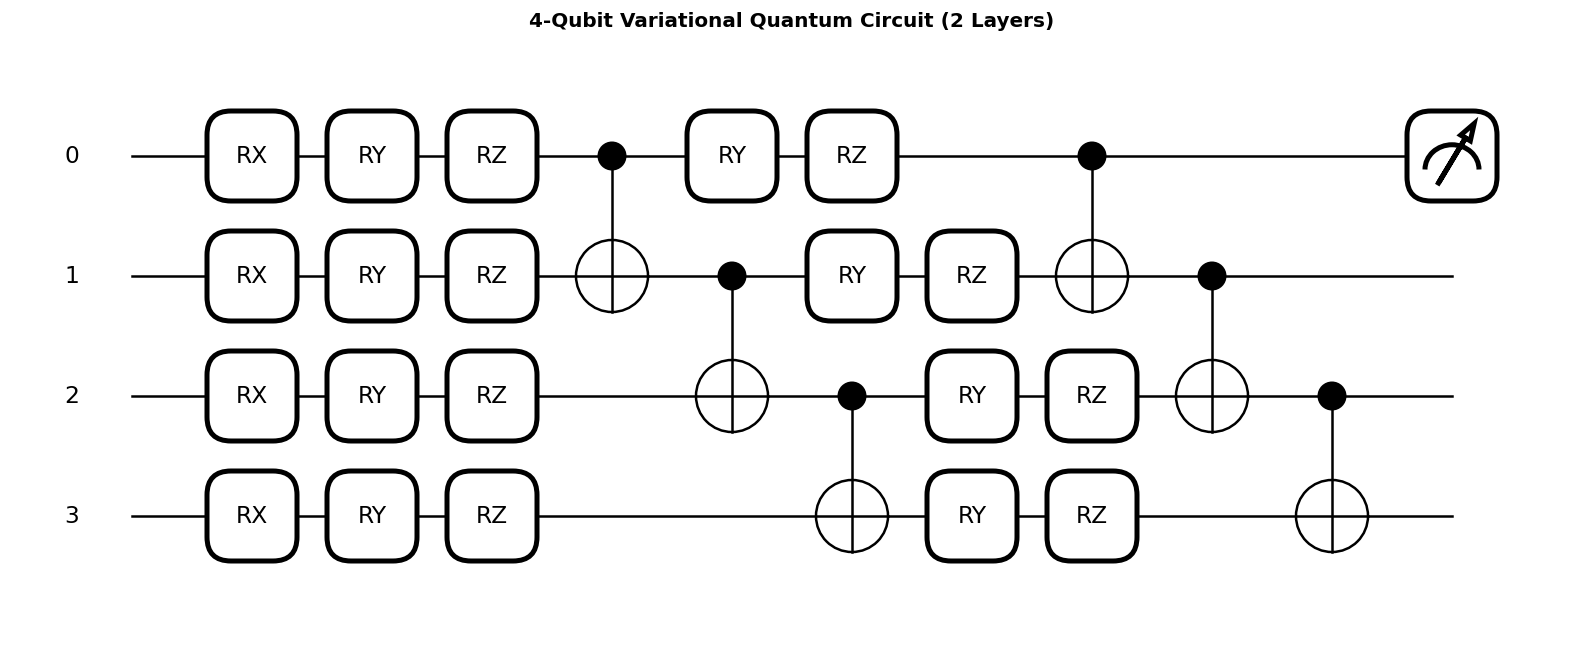

In [7]:
# ============================================================
# Task 2: Visualize the QNN Circuit Architecture
# ============================================================

n_qubits_viz, n_layers_viz = 4, 2
dev_viz = qml.device("default.qubit", wires=n_qubits_viz)

@qml.qnode(dev_viz)
def circuit_viz(params, x):
    for i in range(n_qubits_viz):
        qml.RX(x[i], wires=i)
    for layer in range(n_layers_viz):
        for i in range(n_qubits_viz):
            qml.RY(params[layer, i, 0], wires=i)
            qml.RZ(params[layer, i, 1], wires=i)
        for i in range(n_qubits_viz - 1):
            qml.CNOT(wires=[i, i + 1])
    return qml.expval(qml.PauliZ(0))

dummy_params = pnp.random.randn(n_layers_viz, n_qubits_viz, 2)
dummy_x = pnp.random.randn(n_qubits_viz)
fig, ax = qml.draw_mpl(circuit_viz)(dummy_params, dummy_x)
plt.title("4-Qubit Variational Quantum Circuit (2 Layers)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Task 2: Agent Invocation of QNN Training Tool
# ============================================================

agent_t2 = Agent(
    llm=Claude(model="claude-sonnet-4-0"),
    tools=[train_qnn],
    system_prompt=(
        "You are a quantum machine learning research assistant. You have access "
        "to a tool called train_qnn that trains a Quantum Neural Network on the "
        "MNIST dataset. The tool accepts: epochs (int), learning_rate (float), "
        "n_layers (int, default 2), n_train_samples (int, default 80), and "
        "random_seed (int, default 42). Always use the tool when asked to train. "
        "Summarize results clearly after training."
    ),
    debug=True
)

print("=" * 70)
print("AGENT TRAINING: Agent trains a QNN with specified parameters")
print("=" * 70)
response_t2 = agent_t2.run(
    "Train a quantum neural network with 10 epochs and a learning rate of 0.5. "
    "Use 80 training samples. Report the final accuracy and loss."
)
print(f"\nAgent response:\n{response_t2.text}")
print(f"\nTotal API cost for Task 2: ${agent_t2.get_total_cost():.4f}")

AGENT TRAINING: Agent trains a QNN with specified parameters
Initial response:  [assistant]: I'll train a quantum neural network with your specified parameters: 10 epochs, learning rate of 0.5, and 80 training samples.
                (tool_calls=[ToolCall(called: train_qnn(**{'epochs': 10, 'learning_rate': 0.5, 'n_train_samples': 80}), id=toolu_01PgcUcDydmUBamumHCZq8Ey)])

Iteration count: 0
LLM response after tool calls: Response(model=claude-sonnet-4-0, messages= [assistant]: ## Training Results Summary

The quantum neural network training has been completed successfully! Here are the key results:

### Final Performance
- **Final Loss**: 0.959
- **Final Training Accuracy**: 65.0%
- **Final Test Accuracy**: 59.72%

### Training Configuration
- **Epochs**: 10
- **Learning Rate**: 0.5
- **Training Samples**: 80
- **Layers**: 2 (default)
- **Training Time**: 38.11 seconds

### Training Progress Analysis
The QNN showed interesting training dynamics:
- The loss steadily decreased from 1.2

Running standalone QNN training for visualization...

  Epoch  1/15 | Loss: 1.2576 | Train: 0.5125 | Test: 0.5139
  Epoch  2/15 | Loss: 1.2561 | Train: 0.5125 | Test: 0.5139
  Epoch  3/15 | Loss: 1.2534 | Train: 0.5125 | Test: 0.5139
  Epoch  4/15 | Loss: 1.2487 | Train: 0.5125 | Test: 0.5139
  Epoch  5/15 | Loss: 1.2403 | Train: 0.5125 | Test: 0.5139
  Epoch  6/15 | Loss: 1.2256 | Train: 0.5125 | Test: 0.5139
  Epoch  7/15 | Loss: 1.1998 | Train: 0.5125 | Test: 0.5139
  Epoch  8/15 | Loss: 1.1552 | Train: 0.5125 | Test: 0.5139
  Epoch  9/15 | Loss: 1.0801 | Train: 0.5125 | Test: 0.5139
  Epoch 10/15 | Loss: 0.9593 | Train: 0.6500 | Test: 0.5972
  Epoch 11/15 | Loss: 0.7841 | Train: 1.0000 | Test: 1.0000
  Epoch 12/15 | Loss: 0.5819 | Train: 1.0000 | Test: 1.0000
  Epoch 13/15 | Loss: 0.4203 | Train: 0.9875 | Test: 0.9583
  Epoch 14/15 | Loss: 0.3279 | Train: 0.9625 | Test: 0.9583
  Epoch 15/15 | Loss: 0.2812 | Train: 0.9625 | Test: 0.9444


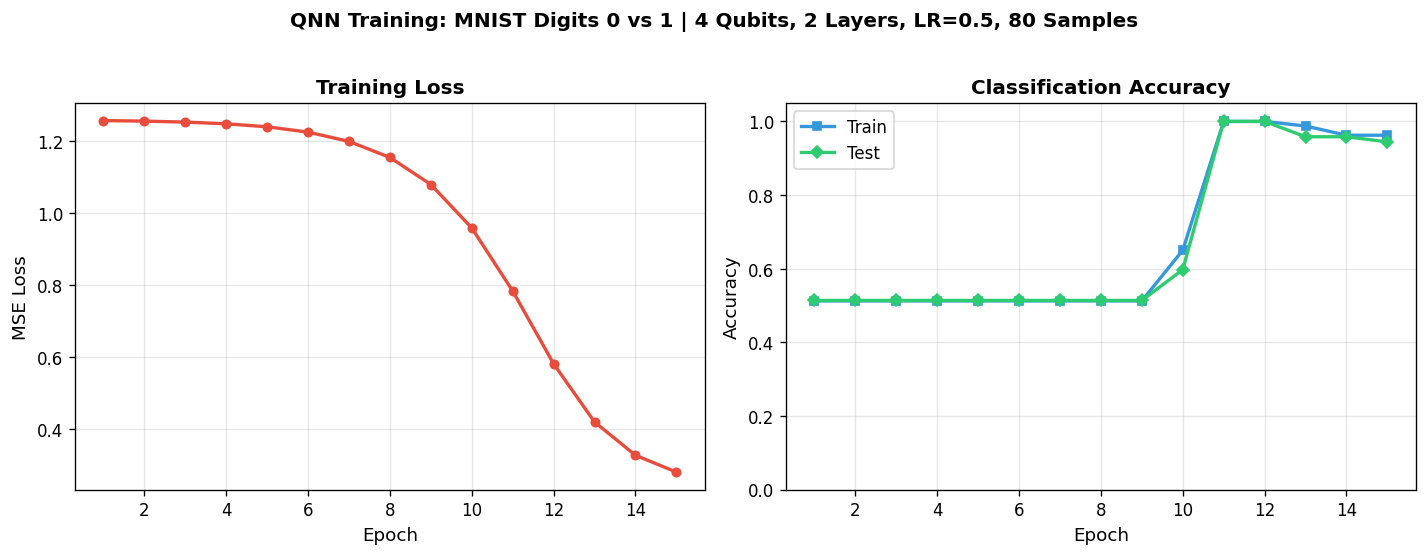


Final: Loss=0.2812, Train Acc=0.9625, Test Acc=0.9444


In [9]:
# ============================================================
# Task 2: Standalone Training Run with Visualization
# ============================================================

print("Running standalone QNN training for visualization...\n")

pnp.random.seed(42)
n_qubits_t, n_layers_t = 4, 2

digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
X_t, y_t = digits.data[mask], digits.target[mask]
y_t = pnp.where(y_t == 0, -1, 1).astype(float)

pca_t = PCA(n_components=n_qubits_t)
X_t = pca_t.fit_transform(X_t)
scaler_t = StandardScaler()
X_t = scaler_t.fit_transform(X_t)
X_t = pnp.array(X_t, requires_grad=False)
y_t = pnp.array(y_t, requires_grad=False)

X_tr, X_te, y_tr, y_te = train_test_split(X_t, y_t, test_size=0.2, random_state=42)
X_tr, y_tr = X_tr[:80], y_tr[:80]

dev_t = qml.device("default.qubit", wires=n_qubits_t)

@qml.qnode(dev_t, interface="autograd")
def qnn_standalone(params, x):
    for i in range(n_qubits_t):
        qml.RX(x[i], wires=i)
    for l in range(n_layers_t):
        for i in range(n_qubits_t):
            qml.RY(params[l, i, 0], wires=i)
            qml.RZ(params[l, i, 1], wires=i)
        for i in range(n_qubits_t - 1):
            qml.CNOT(wires=[i, i + 1])
    return qml.expval(qml.PauliZ(0))

def cost_standalone(p, X, y):
    return pnp.mean((pnp.array([qnn_standalone(p, x) for x in X]) - y) ** 2)

def acc_standalone(p, X, y):
    preds = pnp.array([qnn_standalone(p, x) for x in X])
    return float(pnp.mean(pnp.where(preds >= 0, 1, -1) == y))

params_t = pnp.random.randn(n_layers_t, n_qubits_t, 2, requires_grad=True) * 0.1
opt_t = qml.GradientDescentOptimizer(stepsize=0.5)

losses, train_accs, test_accs = [], [], []
n_epochs_standalone = 15
for ep in range(n_epochs_standalone):
    params_t, lv = opt_t.step_and_cost(lambda p: cost_standalone(p, X_tr, y_tr), params_t)
    ta = acc_standalone(params_t, X_tr, y_tr)
    tea = acc_standalone(params_t, X_te, y_te)
    losses.append(float(lv))
    train_accs.append(ta)
    test_accs.append(tea)
    print(f"  Epoch {ep+1:2d}/{n_epochs_standalone} | Loss: {lv:.4f} | Train: {ta:.4f} | Test: {tea:.4f}")

# --- Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(range(1, n_epochs_standalone+1), losses, 'o-', color='#e74c3c', linewidth=2, markersize=5)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('MSE Loss', fontsize=11)
ax1.set_title('Training Loss', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, n_epochs_standalone+1), train_accs, 's-', color='#3498db', linewidth=2,
         markersize=5, label='Train')
ax2.plot(range(1, n_epochs_standalone+1), test_accs, 'D-', color='#2ecc71', linewidth=2,
         markersize=5, label='Test')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Classification Accuracy', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.suptitle('QNN Training: MNIST Digits 0 vs 1 | 4 Qubits, 2 Layers, LR=0.5, 80 Samples',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"\nFinal: Loss={losses[-1]:.4f}, Train Acc={train_accs[-1]:.4f}, Test Acc={test_accs[-1]:.4f}")

---

## Task 3: Agent-Driven Hyperparameter Optimization

**Objective:** Have the LLM agent autonomously iterate over different learning rates, observe the QNN training metrics, and converge toward an optimal learning rate.

**Approach:** The agent is given a system prompt instructing it to systematically explore learning rates. After each training run, the agent observes the loss and accuracy, reasons about the metric landscape, and selects the next learning rate to try. This creates a **closed-loop optimization** where the LLM acts as the optimizer — the exact pattern needed for automated quantum circuit design.

**Why this matters:** Traditional hyperparameter optimization uses grid search, random search, or Bayesian methods. Here, the LLM brings *reasoning* - it can form hypotheses about why a learning rate worked or failed, apply domain knowledge about gradient dynamics, and make non-trivial decisions. This same reasoning capability, applied to circuit architecture instead of learning rate, is the foundation of the GSoC project.


In [10]:
# ============================================================
# Task 3: Agent-Driven Learning Rate Optimization
# ============================================================

OPTIMIZATION_PROMPT = """You are a quantum machine learning researcher performing hyperparameter optimization on a Quantum Neural Network.

You have access to a tool called `train_qnn` that trains a QNN and returns JSON metrics including final_loss, final_train_accuracy, and final_test_accuracy.

YOUR TASK: Find the best learning rate for the QNN through systematic experimentation.

PROCEDURE:
1. Train with learning_rate=0.1, epochs=10, n_train_samples=80
2. Train with learning_rate=0.5, epochs=10, n_train_samples=80
3. Train with learning_rate=0.05, epochs=10, n_train_samples=80
4. Train with learning_rate=0.3, epochs=10, n_train_samples=80
5. Train with learning_rate=0.8, epochs=10, n_train_samples=80

After ALL 5 runs, provide a comprehensive comparison:
- A summary table showing each learning rate with its final loss and test accuracy
- Which learning rate achieved the BEST test accuracy
- Which learning rate achieved the LOWEST loss
- Your analysis of why certain learning rates performed better
- A recommendation for the optimal learning rate

IMPORTANT: Call train_qnn exactly 5 times. Use epochs=10 and n_train_samples=80 for all runs.
Keep random_seed=42 for fair comparison.
"""

agent_t3 = Agent(
    llm=Claude(model="claude-sonnet-4-0"),
    tools=[train_qnn],
    system_prompt=OPTIMIZATION_PROMPT,
    max_tool_interations=15,
    debug=True
)

print("=" * 70)
print("TASK 3: Agent-Driven Learning Rate Optimization")
print("=" * 70)
print("The agent will autonomously try 5 learning rates, analyze results,")
print("and recommend the optimal configuration.\n")

response_t3 = agent_t3.run(
    "Begin the hyperparameter optimization now. Run all 5 learning rates "
    "as instructed, then give me your final analysis and recommendation."
)

print("\n" + "=" * 70)
print("AGENT'S FINAL OPTIMIZATION REPORT:")
print("=" * 70)
print(response_t3.text)

print(f"\nTotal API cost for Task 3: ${agent_t3.get_total_cost():.4f}")
print(f"Total tokens used: {agent_t3.get_total_tokens()}")

TASK 3: Agent-Driven Learning Rate Optimization
The agent will autonomously try 5 learning rates, analyze results,
and recommend the optimal configuration.

Initial response:  [assistant]: I'll conduct the systematic hyperparameter optimization for the Quantum Neural Network by testing 5 different learning rates. Let me run all the experiments now.
                (tool_calls=[ToolCall(called: train_qnn(**{'learning_rate': 0.1, 'epochs': 10, 'n_train_samples': 80, 'random_seed': 42}), id=toolu_01S7ZrEZRn6qp6yj3if4Q4LS), ToolCall(called: train_qnn(**{'learning_rate': 0.5, 'epochs': 10, 'n_train_samples': 80, 'random_seed': 42}), id=toolu_01SBR7hL4s5pV22UDfQVVXZf), ToolCall(called: train_qnn(**{'learning_rate': 0.05, 'epochs': 10, 'n_train_samples': 80, 'random_seed': 42}), id=toolu_01HbSTxaPXyT6byfm9E1vxXW), ToolCall(called: train_qnn(**{'learning_rate': 0.3, 'epochs': 10, 'n_train_samples': 80, 'random_seed': 42}), id=toolu_01AKjGSNdNbB7FA1u8zRyxzL), ToolCall(called: train_qnn(**{'lear

Reproducing agent's hyperparameter search for visualization...

--- Training with lr=0.1 ---
  Final -> Loss: 1.2534, Train: 0.5125, Test: 0.5139
--- Training with lr=0.5 ---
  Final -> Loss: 0.9593, Train: 0.6500, Test: 0.5972
--- Training with lr=0.05 ---
  Final -> Loss: 1.2561, Train: 0.5125, Test: 0.5139
--- Training with lr=0.3 ---
  Final -> Loss: 1.2089, Train: 0.5125, Test: 0.5139
--- Training with lr=0.8 ---
  Final -> Loss: 0.2943, Train: 0.9625, Test: 0.9444


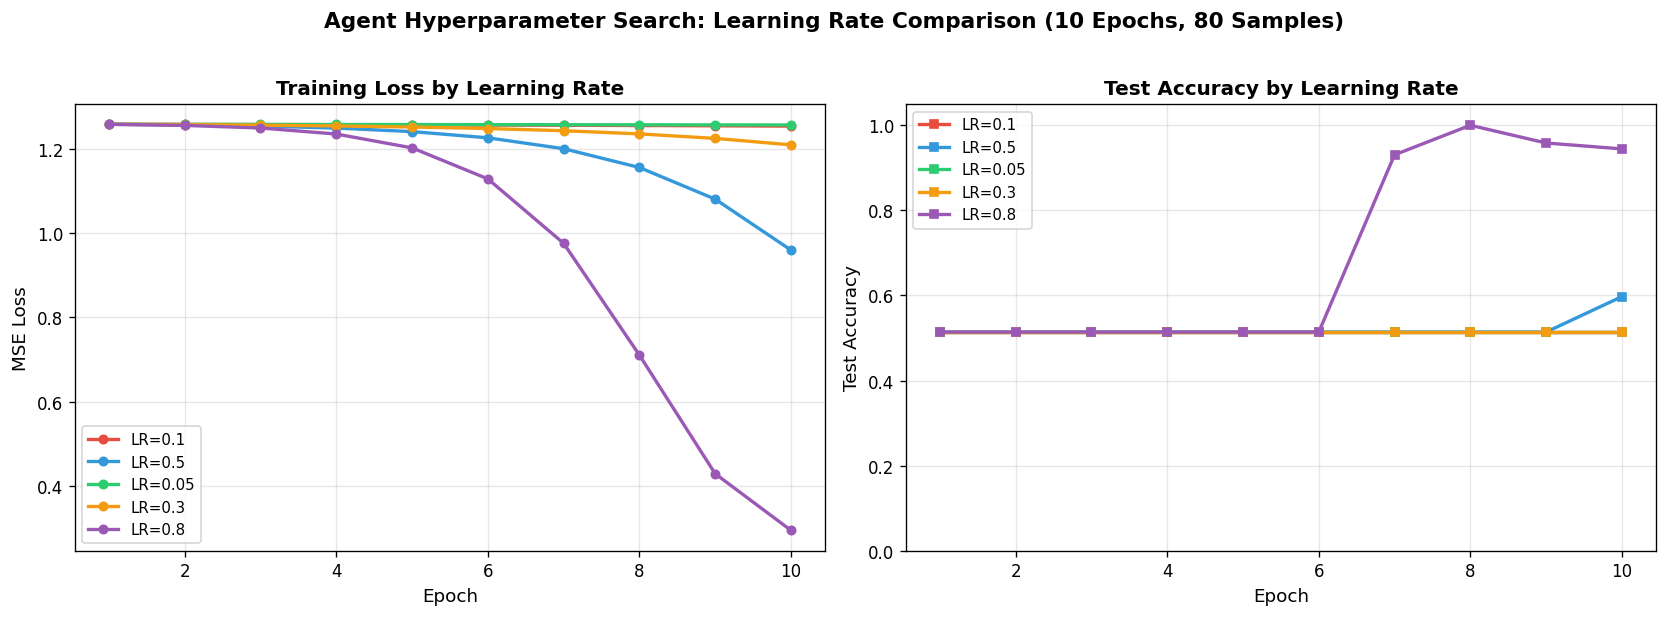

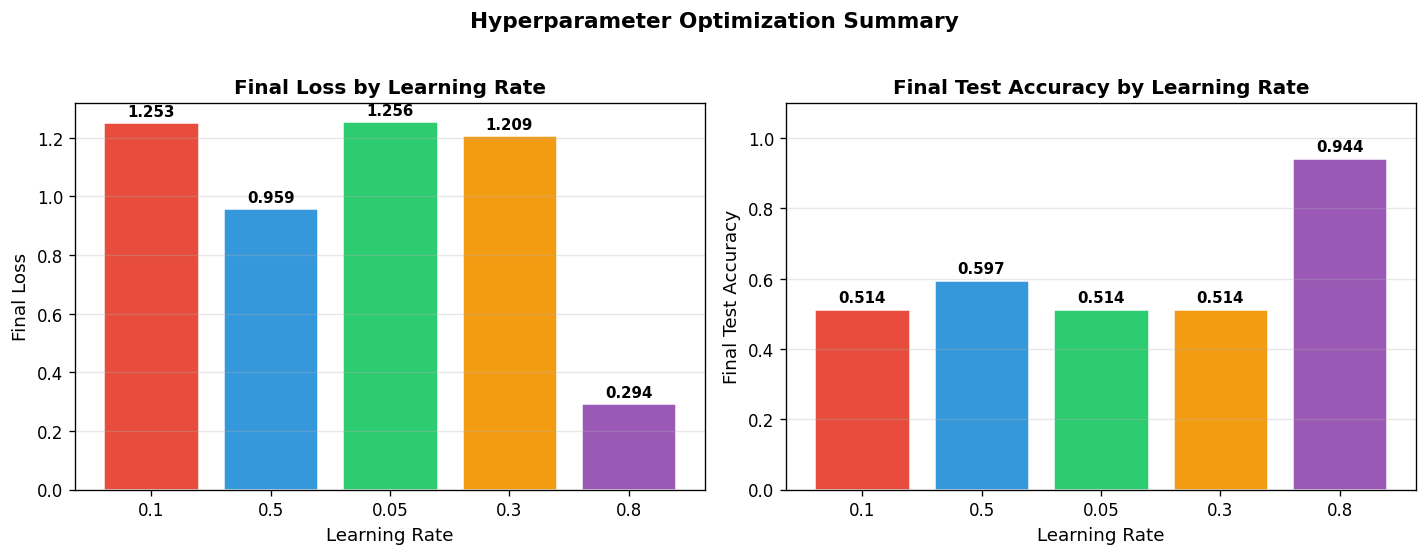


Optimal LR (lowest loss):       0.8 -> Loss: 0.2943
Optimal LR (highest test acc):  0.8 -> Acc: 0.9444


In [11]:
# ============================================================
# Task 3: Visualization of Hyperparameter Search
# ============================================================
# Reproduce the agent's experiments to generate embedded plots.

print("Reproducing agent's hyperparameter search for visualization...\n")

learning_rates_to_test = [0.1, 0.5, 0.05, 0.3, 0.8]
all_results = {}

for lr in learning_rates_to_test:
    print(f"--- Training with lr={lr} ---")
    pnp.random.seed(42)
    n_q, n_l = 4, 2

    digits = load_digits()
    mask = (digits.target == 0) | (digits.target == 1)
    X_hp, y_hp = digits.data[mask], digits.target[mask]
    y_hp = pnp.where(y_hp == 0, -1, 1).astype(float)
    pca_hp = PCA(n_components=n_q)
    X_hp = pca_hp.fit_transform(X_hp)
    scaler_hp = StandardScaler()
    X_hp = scaler_hp.fit_transform(X_hp)
    X_hp = pnp.array(X_hp, requires_grad=False)
    y_hp = pnp.array(y_hp, requires_grad=False)
    X_trh, X_teh, y_trh, y_teh = train_test_split(X_hp, y_hp, test_size=0.2, random_state=42)
    X_trh, y_trh = X_trh[:80], y_trh[:80]

    dev_hp = qml.device("default.qubit", wires=n_q)

    @qml.qnode(dev_hp, interface="autograd")
    def qnn_hp(params, x):
        for i in range(n_q):
            qml.RX(x[i], wires=i)
        for layer in range(n_l):
            for i in range(n_q):
                qml.RY(params[layer, i, 0], wires=i)
                qml.RZ(params[layer, i, 1], wires=i)
            for i in range(n_q - 1):
                qml.CNOT(wires=[i, i + 1])
        return qml.expval(qml.PauliZ(0))

    def cost_hp(p, X, y):
        return pnp.mean((pnp.array([qnn_hp(p, x) for x in X]) - y) ** 2)

    def acc_hp(p, X, y):
        preds = pnp.array([qnn_hp(p, x) for x in X])
        return float(pnp.mean(pnp.where(preds >= 0, 1, -1) == y))

    params_hp = pnp.random.randn(n_l, n_q, 2, requires_grad=True) * 0.1
    opt_hp = qml.GradientDescentOptimizer(stepsize=lr)

    lr_losses, lr_train_accs, lr_test_accs = [], [], []
    for ep in range(10):
        params_hp, lv = opt_hp.step_and_cost(lambda p: cost_hp(p, X_trh, y_trh), params_hp)
        lr_losses.append(float(lv))
        lr_train_accs.append(acc_hp(params_hp, X_trh, y_trh))
        lr_test_accs.append(acc_hp(params_hp, X_teh, y_teh))

    all_results[lr] = {"losses": lr_losses, "train_accs": lr_train_accs, "test_accs": lr_test_accs}
    print(f"  Final -> Loss: {lr_losses[-1]:.4f}, Train: {lr_train_accs[-1]:.4f}, Test: {lr_test_accs[-1]:.4f}")

# --- Plot 1: Loss & Accuracy curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for (lr, res), color in zip(all_results.items(), colors):
    ax1.plot(range(1, 11), res["losses"], 'o-', color=color, linewidth=2,
             markersize=5, label=f'LR={lr}')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('MSE Loss', fontsize=11)
ax1.set_title('Training Loss by Learning Rate', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

for (lr, res), color in zip(all_results.items(), colors):
    ax2.plot(range(1, 11), res["test_accs"], 's-', color=color, linewidth=2,
             markersize=5, label=f'LR={lr}')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Test Accuracy', fontsize=11)
ax2.set_title('Test Accuracy by Learning Rate', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.suptitle('Agent Hyperparameter Search: Learning Rate Comparison (10 Epochs, 80 Samples)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Plot 2: Final metrics bar chart ---
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4.5))

lrs_str = [str(lr) for lr in learning_rates_to_test]
final_losses = [all_results[lr]["losses"][-1] for lr in learning_rates_to_test]
final_accs = [all_results[lr]["test_accs"][-1] for lr in learning_rates_to_test]

bars1 = ax3.bar(lrs_str, final_losses, color=colors, edgecolor='white', linewidth=1.5)
ax3.set_xlabel('Learning Rate', fontsize=11)
ax3.set_ylabel('Final Loss', fontsize=11)
ax3.set_title('Final Loss by Learning Rate', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, final_losses):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

bars2 = ax4.bar(lrs_str, final_accs, color=colors, edgecolor='white', linewidth=1.5)
ax4.set_xlabel('Learning Rate', fontsize=11)
ax4.set_ylabel('Final Test Accuracy', fontsize=11)
ax4.set_title('Final Test Accuracy by Learning Rate', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 1.1)
for bar, val in zip(bars2, final_accs):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Hyperparameter Optimization Summary', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
best_loss_lr = min(all_results.keys(), key=lambda lr: all_results[lr]["losses"][-1])
best_acc_lr = max(all_results.keys(), key=lambda lr: all_results[lr]["test_accs"][-1])
print(f"\nOptimal LR (lowest loss):       {best_loss_lr} -> Loss: {all_results[best_loss_lr]['losses'][-1]:.4f}")
print(f"Optimal LR (highest test acc):  {best_acc_lr} -> Acc: {all_results[best_acc_lr]['test_accs'][-1]:.4f}")

---

## Conclusion

This notebook demonstrates a complete **agentic quantum machine learning** pipeline:

1. **Task 1** — Created a custom Orchestral AI tool (`hilbert_space_dimension`) with a rich docstring enabling Claude to reliably invoke it for quantum state space calculations, including multi-call and contextual reasoning scenarios.

2. **Task 2** — Built a 4-qubit Variational Quantum Circuit using PennyLane with angle embedding, parametrized RY/RZ rotations, and CNOT entanglement for binary MNIST classification. The entire training pipeline is wrapped as an Orchestral AI tool (`train_qnn`) with configurable hyperparameters, returning structured JSON metrics.

3. **Task 3** — Implemented a closed-loop agent-driven optimization pipeline where Claude systematically explores learning rates, observes training metrics, and identifies optimal configurations through reasoning — the core pattern for automated quantum circuit design.

**Key Design Decisions:**
- **PennyLane over Qiskit:** PennyLane's autograd interface enables seamless gradient-based VQC optimization without PyTorch/TensorFlow, keeping the stack lightweight and reproducible.
- **Binary MNIST with PCA:** 2-class classification reduced to 4 PCA components makes quantum simulation tractable while demonstrating a meaningful learning task.
- **Structured JSON output:** Machine-parseable metrics enable the agent to programmatically reason about performance rather than parsing free text.
- **`@define_tool()` with detailed docstrings:** Orchestral AI's type-hint-based schema generation, combined with comprehensive docstrings, lets the LLM understand tool capabilities without explicit prompt engineering.

**Extension to full project scope:** Replace the fixed QNN architecture with a circuit-generating tool and the learning rate search with architecture search, and this same closed-loop pattern becomes the automated quantum circuit design framework the GSoC project envisions.
